This is for matching Figure 4.7 in Schuttrups

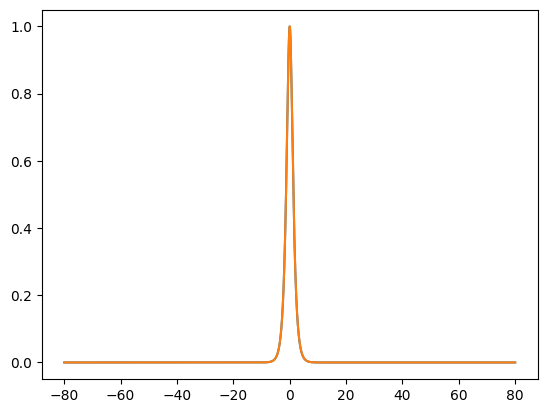

In [1]:
import numpy as np
import matplotlib.pyplot as plt

tau = np.linspace(-80, 80, 8192)
xi_max = 10 * np.pi / 2

L2_norm = lambda x, y: np.sqrt(np.trapezoid(np.abs(y) ** 2, x))

def test_cases(N):
    if N == 1:
        return lambda xi: 1 / np.cosh(tau) * np.exp(1j * xi / 2)
    elif N == 2:
        return lambda xi: 4 * np.exp(1j * xi / 2) * ( np.cosh(3 * tau) + 3 * np.exp(4j * xi) * np.cosh(tau) ) / ( np.cosh(4 * tau) + 4 * np.cosh(2 * tau) + 3 * np.cos(4 * xi) )
    else:
        raise NotImplementedError

plt.plot(tau, np.abs(test_cases(1)(xi_max) / 1))
plt.plot(tau, np.abs(test_cases(2)(xi_max) / 2))

In [2]:
from NLSE import split_step

beta2_sign = -1

def nl_operator(u):
    return 1j * np.abs(u) ** 2

def diff_operator(omega):
    return 1j * beta2_sign / 2 * omega ** 2

def find_error(N, steps):
    u_gt = test_cases(N)
    xi = np.linspace(0, xi_max, steps)
    u = split_step(u_gt(0), tau, xi, diff_operator, nl_operator)
    
    e = u[-1] - u_gt(xi[-1])
    error = L2_norm(tau, e) / L2_norm(tau, u_gt(xi[-1]))
    return error

In [3]:
computational_steps = ( np.round( 10 ** np.linspace(2,5,10) ) + 1 ).astype(int)
error_n1 = [ find_error(1, n_steps) for n_steps in computational_steps ]
error_n2 = [ find_error(2, n_steps) for n_steps in computational_steps ]

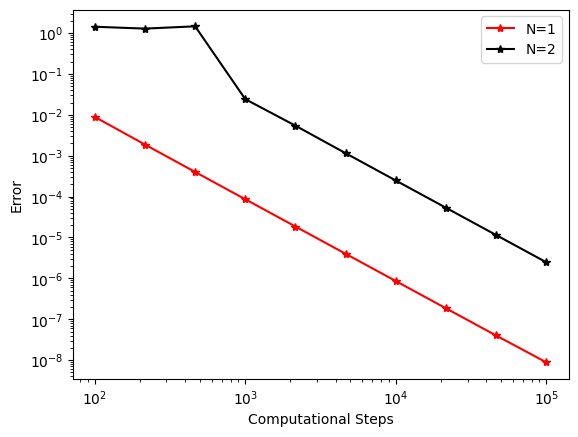

In [4]:
plt.plot(computational_steps, error_n1, 'r-*', label='N=1')
plt.plot(computational_steps, error_n2, 'k-*', label='N=2')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Computational Steps')
plt.ylabel('Error')
plt.legend()